# TND FairFlow Engine  
## Real-Time Intrinsic Valuation and Liquidity Pressure Modeling for USD/TND

**Time Series Analysis Project**  
**Instructor:** Dr. Eymen Errais  

This notebook presents a complete valuation framework for USD/TND that combines global foreign-exchange fundamentals with Tunisian interbank liquidity pressure. The objective is to estimate a fair value for USD/TND that is more informative than the official fixing alone, especially when local market conditions cause the traded interbank rate to deviate from the benchmark.

## 1. Executive Introduction

The official USD/TND fixing published by the Central Bank of Tunisia provides a benchmark exchange rate, but it does not always represent the rate at which banks are willing to trade in the interbank market. In practice, the interbank rate may move above or below the official fixing because of local liquidity conditions, foreign-currency scarcity, risk appetite, balance-sheet constraints, and temporary supply-demand imbalances.

The valuation problem is therefore two-dimensional. First, USD/TND must respond to global currency movements, especially EUR/USD, GBP/USD, and USD/JPY. Second, the model must recognize that Tunisian market frictions can create a local premium or discount relative to the official reference rate.

The **TND FairFlow Engine** estimates USD/TND intrinsic value as:

$$
\text{Intrinsic USD/TND}_t
=
\underbrace{\text{Global Basket Baseline}_t}_{\text{fundamental anchor}}
+
\underbrace{\text{Estimated Local Liquidity Adjustment}_t}_{\text{market pressure}}
$$

The basket component captures global FX fundamentals. The liquidity component captures the spread between the BCT fixing and the interbank market rate. Together, they produce a finance-aware fair-value signal that can support treasury monitoring, market-risk analysis, and central-bank-style exchange-rate diagnostics.

## 2. Data Pipeline

The dataset contains four market blocks:

1. **BCT Fixing USD/TND** — official USD/TND fixing data.  
2. **BCT Fixing EUR/TND** — official EUR/TND fixing data, used as an additional local reference.  
3. **InterBancaire USD/TND** — bid, ask, and mid-price observations for the Tunisian interbank market.  
4. **Global FX basket variables** — EUR/USD, GBP/USD, and USD/JPY.

The interbank mid-price is treated as the closest available proxy for the true market USD/TND rate. The official fixing is treated as the public benchmark. The difference between both is the observed local liquidity spread.

All time series are converted to datetime format, sorted chronologically, deduplicated, merged on exchange date, and cleaned for missing values. The final modeling dataset is daily because the available files are daily. The architecture, however, is written so that higher-frequency global FX observations could be inserted later for intraday nowcasting.

## 3. Exploratory Data Analysis

The exploratory stage studies the relationship between the official fixing, the interbank market rate, and global FX drivers. The main objective is not only statistical description, but also financial interpretation.

The most important diagnostic is the interbank-fixing spread:

$$
Spread_t = IB_t - Fixing_t
$$

A positive spread means that USD is trading above the official fixing in the interbank market. This can indicate pressure for foreign currency, thinner liquidity, or higher demand for USD. A negative spread indicates that interbank pricing is below the fixing, suggesting easier local liquidity or a discount relative to the benchmark.

### 3.1 Formal Econometric Diagnostics: Forward Reference

The formal stationarity tests, residual diagnostics, HAC-robust standard errors, and forecast-efficiency tests are reported after the basket model is estimated. This placement ensures that all required objects, including `df_model` and `basket_log_model`, are defined before the diagnostic code is executed.

In [1]:
# ================================
# 3.1 Environment and file loading
# ================================

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.api import OLS, add_constant

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# In Google Colab, upload the four CSV files when prompted.
try:
    from google.colab import files as colab_files
    if len(glob.glob('/content/*.csv')) < 4:
        print("Upload the four project CSV files now.")
        uploaded = colab_files.upload()
except Exception:
    pass

DATA_DIRS = [".", "/content", "/mnt/data"]

def locate_file(keywords):
    # Find a file whose name contains all supplied keywords, robust to spacing/case.
    candidates = []
    for d in DATA_DIRS:
        candidates.extend(glob.glob(os.path.join(d, "*.csv")))
    for path in candidates:
        name = os.path.basename(path).lower().replace(" ", "")
        if all(k.lower().replace(" ", "") in name for k in keywords):
            return path
    available = [os.path.basename(x) for x in candidates]
    raise FileNotFoundError(f"Could not locate file containing keywords {keywords}. Available CSV files: {available}")

FILE_PATHS = {
    "fix_usd": locate_file(["BCT", "Fixing", "USD"]),
    "fix_eur": locate_file(["BCT", "Fixing", "EUR"]),
    "interbank": locate_file(["InterBancaire"]),
    "global_fx": locate_file(["EUR", "GBP", "JPY", "USD"]),
}

FILE_PATHS


Upload the four project CSV files now.


Saving FX Data.xlsx - InterBancaire (1).csv to FX Data.xlsx - InterBancaire (1).csv
Saving FX Data.xlsx - EUR-GBP-JPY vs USD.csv to FX Data.xlsx - EUR-GBP-JPY vs USD.csv
Saving FX Data.xlsx - BCT Fixing USD.csv to FX Data.xlsx - BCT Fixing USD.csv
Saving FX Data.xlsx - BCT Fixing EUR.csv to FX Data.xlsx - BCT Fixing EUR.csv


{'fix_usd': './FX Data.xlsx - BCT Fixing USD.csv',
 'fix_eur': './FX Data.xlsx - BCT Fixing EUR.csv',
 'interbank': './FX Data.xlsx - InterBancaire (1).csv',
 'global_fx': './FX Data.xlsx - EUR-GBP-JPY vs USD.csv'}

In [2]:
# ================================
# 3.2 Reusable cleaning functions
# ================================

def parse_date_safe(x):
    return pd.to_datetime(x, errors="coerce", dayfirst=True)


def load_bct_fixing(path, output_col):
    raw = pd.read_csv(path)
    raw.columns = [str(c).strip() for c in raw.columns]
    date_col = "Exchange Date" if "Exchange Date" in raw.columns else raw.columns[0]
    mid_col = "Mid Price" if "Mid Price" in raw.columns else raw.columns[-1]
    out = pd.DataFrame({
        "date": parse_date_safe(raw[date_col]),
        output_col: pd.to_numeric(raw[mid_col], errors="coerce")
    })
    return out.dropna().sort_values("date").drop_duplicates("date")


def load_interbank(path):
    raw = pd.read_csv(path)
    raw.columns = [str(c).strip() for c in raw.columns]
    out = pd.DataFrame({
        "date": parse_date_safe(raw["Date"]),
        "usd_tnd_ib": pd.to_numeric(raw["USD"], errors="coerce")
    })
    return out.dropna().sort_values("date").drop_duplicates("date")


def load_global_fx(path):
    raw = pd.read_csv(path)
    raw.columns = [str(c).strip() for c in raw.columns]
    out = pd.DataFrame({
        "date": parse_date_safe(raw["Date"]),
        "eurusd": pd.to_numeric(raw[[c for c in raw.columns if "EUR" in c][0]], errors="coerce"),
        "gbpusd": pd.to_numeric(raw[[c for c in raw.columns if "GBP" in c][0]], errors="coerce"),
        "usdjpy": pd.to_numeric(raw[[c for c in raw.columns if "JPY" in c][0]], errors="coerce"),
    })
    return out.dropna().sort_values("date").drop_duplicates("date")

fix_usd = load_bct_fixing(FILE_PATHS["fix_usd"], "usd_tnd_fix")
fix_eur = load_bct_fixing(FILE_PATHS["fix_eur"], "eur_tnd_fix")
ib = load_interbank(FILE_PATHS["interbank"])
global_fx = load_global_fx(FILE_PATHS["global_fx"])

print("BCT USD fixing:", fix_usd.shape)
print("BCT EUR fixing:", fix_eur.shape)
print("Interbank:", ib.shape)
print("Global FX:", global_fx.shape)


BCT USD fixing: (1462, 2)
BCT EUR fixing: (1501, 2)
Interbank: (3176, 2)
Global FX: (1513, 4)


In [3]:
# ================================
# 3.3 Data alignment and feature engineering
# ================================

df = (
    fix_usd
    .merge(fix_eur, on="date", how="inner")
    .merge(ib, on="date", how="inner")
    .merge(global_fx, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

df["spread"] = df["usd_tnd_ib"] - df["usd_tnd_fix"]
df["spread_bps"] = 10000 * df["spread"] / df["usd_tnd_fix"]

for col in ["usd_tnd_fix", "usd_tnd_ib", "eur_tnd_fix", "eurusd", "gbpusd", "usdjpy"]:
    df[f"r_{col}"] = np.log(df[col]).diff()

for col in ["usd_tnd_fix", "eurusd", "gbpusd", "usdjpy"]:
    df[f"pct_{col}"] = df[col].pct_change()

df["spread_lag1"] = df["spread"].shift(1)
df["spread_lag2"] = df["spread"].shift(2)
df["spread_roll_mean_20"] = df["spread"].rolling(20).mean()
df["spread_roll_vol_20"] = df["spread"].rolling(20).std()
df["actual_next_ib"] = df["usd_tnd_ib"].shift(-1)
df["target_date"] = df["date"].shift(-1)

df_model = df.dropna(subset=["r_usd_tnd_fix", "r_eurusd", "r_gbpusd", "r_usdjpy", "spread_lag1"]).copy()
print(f"Aligned sample: {df['date'].min().date()} to {df['date'].max().date()}, observations = {len(df)}")
df.head()


Aligned sample: 2020-04-10 to 2025-12-11, observations = 553


,date,usd_tnd_fix,eur_tnd_fix,usd_tnd_ib,eurusd,gbpusd,usdjpy,spread,spread_bps,r_usd_tnd_fix,r_usd_tnd_ib,r_eur_tnd_fix,r_eurusd,r_gbpusd,r_usdjpy,pct_usd_tnd_fix,pct_eurusd,pct_gbpusd,pct_usdjpy,spread_lag1,spread_lag2,spread_roll_mean_20,spread_roll_vol_20,actual_next_ib,target_date
0,2020-04-10,2.906400,3.160200,2.767800,1.093500,1.245200,108.460000,-0.138600,-476.878613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.922500,2020-05-04
1,2020-05-04,2.890300,3.161200,2.922500,1.090600,1.244200,106.730000,0.032200,111.407120,-0.005555,0.054387,0.000316,-0.002656,-0.000803,-0.016079,-0.005539,-0.002652,-0.000803,-0.015951,-0.138600,NaN,NaN,NaN,2.903900,2020-05-05
2,2020-05-05,2.907000,3.150000,2.903900,1.083800,1.243400,106.580000,-0.003100,-10.663915,0.005761,-0.006385,-0.003549,-0.006255,-0.000643,-0.001406,0.005778,-0.006235,-0.000643,-0.001405,0.032200,-0.138600,NaN,NaN,2.851200,2020-05-06
3,2020-05-06,2.912500,3.146100,2.851200,1.079400,1.234100,106.140000,-0.061300,-210.472103,0.001890,-0.018315,-0.001239,-0.004068,-0.007508,-0.004137,0.001892,-0.004060,-0.007479,-0.004128,-0.003100,0.032200,NaN,NaN,2.861200,2020-05-07
4,2020-05-07,2.914800,3.145700,2.861200,1.083200,1.236100,106.270000,-0.053600,-183.889118,0.000789,0.003501,-0.000127,0.003514,0.001619,0.001224,0.000790,0.003520,0.001621,0.001225,-0.061300,-0.003100,NaN,NaN,2.734900,2020-05-08


## 4. Basket Model Design

The baseline model estimates the fundamental USD/TND anchor implied by global FX movements. The project brief identifies EUR/USD, GBP/USD, and USD/JPY as key drivers, so the model links changes in USD/TND to changes in those major currency pairs.

The conceptual relationship is:

$$
USD/TND_t = f(EUR/USD_t,\; GBP/USD_t,\; USD/JPY_t)
$$

The preferred specification uses log returns:

$$
\Delta \log(USD/TND_t)
=
\alpha
+
\beta_1 \Delta \log(EUR/USD_t)
+
\beta_2 \Delta \log(GBP/USD_t)
+
\beta_3 \Delta \log(USD/JPY_t)
+
\varepsilon_t
$$

Log returns are used because they stabilize the time series, make coefficients easier to interpret as elasticities, and reduce the risk of spurious regression in exchange-rate levels. The estimated coefficients represent the sensitivity of the official USD/TND fixing to each global FX movement.

In [4]:
# ================================
# 4.1 Descriptive statistics
# ================================

summary_cols = ["usd_tnd_fix", "usd_tnd_ib", "spread", "spread_bps", "eurusd", "gbpusd", "usdjpy"]
eda_summary = df[summary_cols].describe().T
eda_summary


,count,mean,std,min,25%,50%,75%,max
usd_tnd_fix,553.000000,2.985622,0.160759,2.677500,2.840500,3.047600,3.116700,3.273700
usd_tnd_ib,553.000000,2.996282,0.159231,2.690200,2.847900,3.053100,3.122900,3.319700
spread,553.000000,0.010660,0.112715,-0.350900,-0.037600,0.006100,0.060700,0.429500
spread_bps,553.000000,43.141957,376.828832,"-1,087.050805",-123.923175,19.939233,214.413722,"1,492.459518"
eurusd,553.000000,1.111577,0.059306,0.970000,1.072900,1.096000,1.165900,1.232500
gbpusd,553.000000,1.289261,0.064406,1.096300,1.248100,1.280400,1.341300,1.417800
usdjpy,553.000000,131.997776,18.398673,102.720000,110.600000,136.560000,147.680000,161.680000


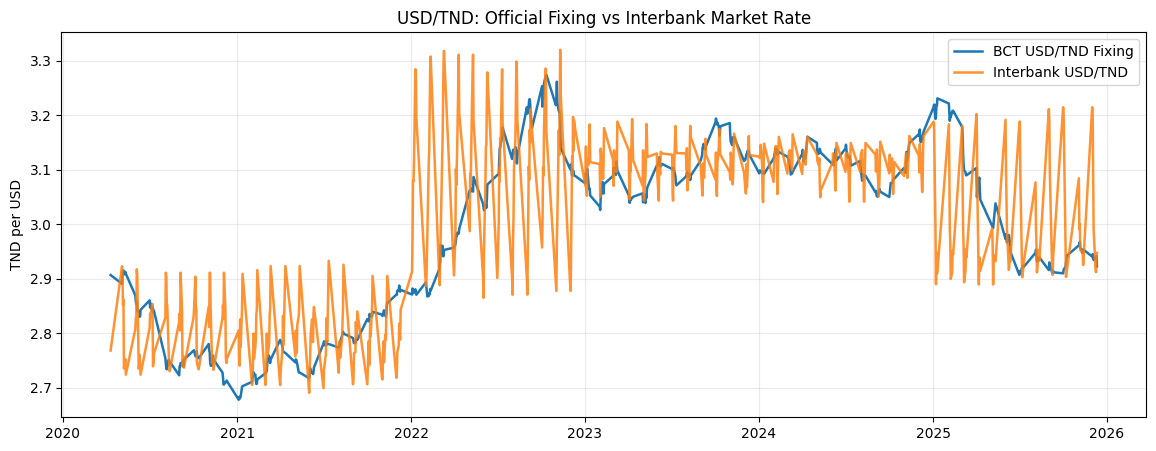

In [5]:
# ================================
# 4.2 Fixing vs interbank
# ================================

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df["date"], df["usd_tnd_fix"], label="BCT USD/TND Fixing", linewidth=1.8)
ax.plot(df["date"], df["usd_tnd_ib"], label="Interbank USD/TND", linewidth=1.8, alpha=0.85)
ax.set_title("USD/TND: Official Fixing vs Interbank Market Rate")
ax.set_ylabel("TND per USD")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


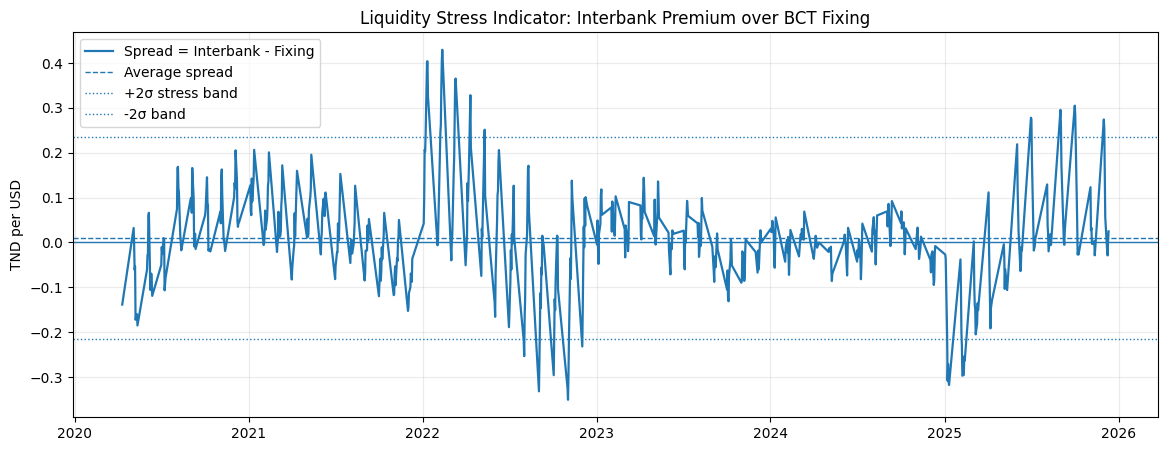

In [6]:
# ================================
# 4.3 Liquidity stress spread
# ================================

spread_mu = df["spread"].mean()
spread_sigma = df["spread"].std()

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df["date"], df["spread"], label="Spread = Interbank - Fixing", linewidth=1.6)
ax.axhline(0, linewidth=1)
ax.axhline(spread_mu, linestyle="--", linewidth=1, label="Average spread")
ax.axhline(spread_mu + 2*spread_sigma, linestyle=":", linewidth=1, label="+2σ stress band")
ax.axhline(spread_mu - 2*spread_sigma, linestyle=":", linewidth=1, label="-2σ band")
ax.set_title("Liquidity Stress Indicator: Interbank Premium over BCT Fixing")
ax.set_ylabel("TND per USD")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


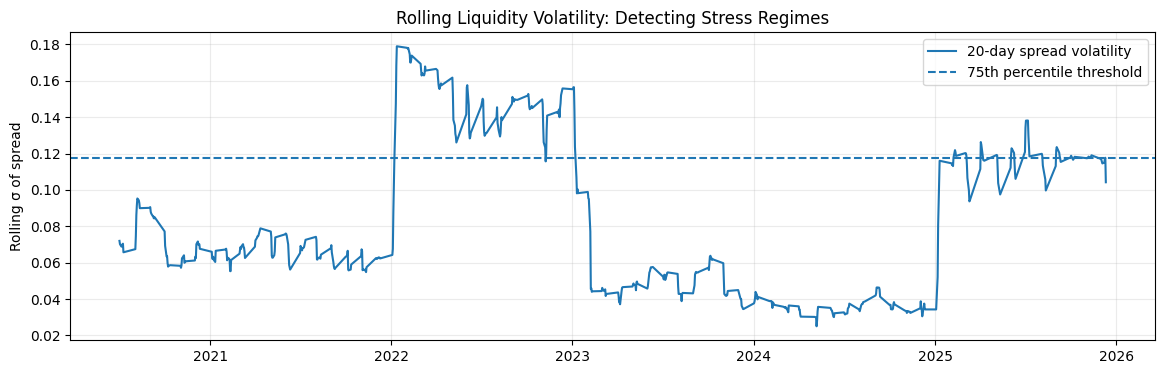

In [7]:
# ================================
# 4.4 Rolling volatility and regimes
# ================================

df["spread_vol_20"] = df["spread"].rolling(20).std()
threshold = df["spread_vol_20"].quantile(0.75)
df["stress_regime"] = np.where(df["spread_vol_20"] > threshold, "High Stress", "Normal")

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df["date"], df["spread_vol_20"], label="20-day spread volatility")
ax.axhline(threshold, linestyle="--", label="75th percentile threshold")
ax.set_title("Rolling Liquidity Volatility: Detecting Stress Regimes")
ax.set_ylabel("Rolling σ of spread")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


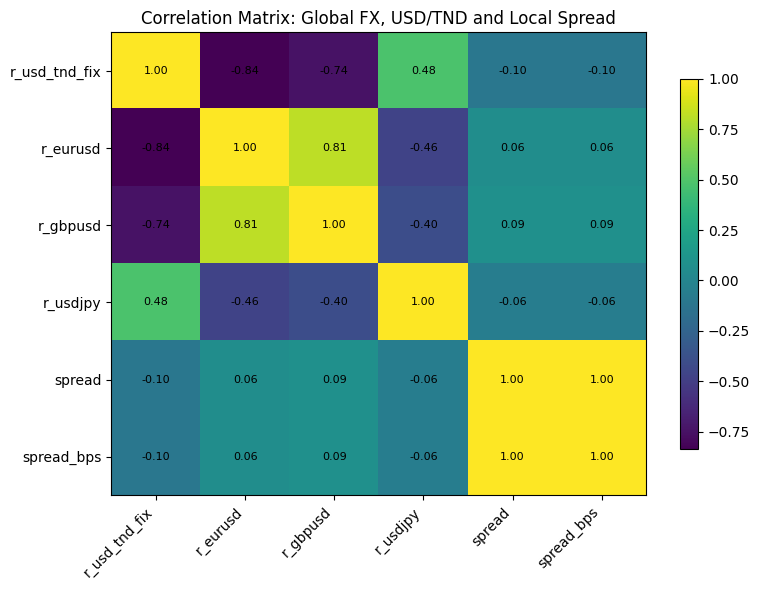

In [8]:
# ================================
# 4.5 Correlation heatmap
# ================================

corr_cols = ["r_usd_tnd_fix", "r_eurusd", "r_gbpusd", "r_usdjpy", "spread", "spread_bps"]
corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Matrix: Global FX, USD/TND and Local Spread")
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## 5. From Regression to Baseline Engine

The regression produces an expected USD/TND return. To convert that return into a level-based fair-value anchor, the model compounds the predicted return from the previous official fixing:

$$
\widehat{Baseline}_t
=
Fixing_{t-1} \cdot \exp(\widehat{r}_t)
$$

This baseline is the value of USD/TND implied by international currency movements alone. It deliberately excludes local Tunisian liquidity pressure. That separation is important because it allows the model to distinguish between global fundamental movement and domestic market friction.

## 6. Fixing Choice and Real-Time Interpretation

The project brief raises an important research question: should the liquidity adjustment be modeled against the morning fixing, evening fixing, or previous-day fixing?

The available data is daily, so this implementation uses the daily BCT mid-price as the official benchmark. In a live intraday deployment, the preferred real-time anchor would be the latest available fixing at the time of valuation. During the trading day, the engine would update the basket baseline using live global FX rates while carrying forward the most recent official BCT benchmark.

The real-time version can be expressed as:

$$
\widehat{Baseline}^{RT}_t
=
Fixing_{t_0}
\cdot
\exp\left(
\widehat{r}_{t_0 \rightarrow t}
\right)
$$

where \(t_0\) is the time of the latest available BCT fixing and \(t\) is the current valuation time. The current notebook is therefore a daily prototype of a real-time architecture, not a purely static historical model.

In [9]:
# ================================
# 5.1 Static basket model: log returns
# ================================

basket_vars = ["r_eurusd", "r_gbpusd", "r_usdjpy"]
train_end = int(len(df_model) * 0.75)
train = df_model.iloc[:train_end].copy()

X_train = add_constant(train[basket_vars])
y_train = train["r_usd_tnd_fix"]
X_all = add_constant(df_model[basket_vars])

# Newey-West / HAC robust covariance is used because FX residuals can be
# heteroskedastic and serially correlated. Coefficients are unchanged, but
# statistical inference becomes more appropriate for financial time series.
basket_log_model = OLS(y_train, X_train).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
df_model["basket_return_static"] = basket_log_model.predict(X_all)
print(basket_log_model.summary())


                            OLS Regression Results                            
Dep. Variable:          r_usd_tnd_fix   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     138.0
Date:                Mon, 04 May 2026   Prob (F-statistic):           8.35e-62
Time:                        14:11:52   Log-Likelihood:                 1841.9
No. Observations:                 414   AIC:                            -3676.
Df Residuals:                     410   BIC:                            -3660.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   7.61e-05      1.683      0.0

### 5.1.1 Stationarity Tests: ADF and KPSS

Before interpreting the basket regression, the key exchange-rate variables are tested for stationarity. The ADF test treats a unit root as the null hypothesis, while the KPSS test treats stationarity as the null hypothesis. This combination provides a more complete view of whether the model should be estimated in levels or returns.

In [10]:
# ================================
# 5.1.1 Stationarity tests: ADF and KPSS
# ================================

from statsmodels.tsa.stattools import adfuller, kpss
import warnings

def stationarity_report(series, name):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 20:
        return {"Series": name, "ADF Statistic": np.nan, "ADF p-value": np.nan, "KPSS Statistic": np.nan, "KPSS p-value": np.nan, "Interpretation": "Insufficient observations"}
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
        except Exception:
            kpss_stat, kpss_p = np.nan, np.nan
    if adf_p < 0.05 and (pd.isna(kpss_p) or kpss_p > 0.05):
        interp = "Stationary"
    elif adf_p >= 0.05 and (pd.isna(kpss_p) or kpss_p <= 0.05):
        interp = "Likely non-stationary"
    else:
        interp = "Mixed evidence"
    return {"Series": name, "ADF Statistic": adf_stat, "ADF p-value": adf_p, "KPSS Statistic": kpss_stat, "KPSS p-value": kpss_p, "Interpretation": interp}

candidate_series = {
    "USD/TND Fixing Level": "usd_tnd_fix",
    "Interbank USD/TND Level": "usd_tnd_ib",
    "Liquidity Spread": "spread",
    "USD/TND Fixing Return": "r_usd_tnd_fix",
    "EUR/USD Return": "r_eurusd",
    "GBP/USD Return": "r_gbpusd",
    "USD/JPY Return": "r_usdjpy",
}
stationarity_results = pd.DataFrame([stationarity_report(df_model[col], label) for label, col in candidate_series.items() if col in df_model.columns])
stationarity_results


,Series,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value,Interpretation
0,USD/TND Fixing Level,-1.178217,0.682895,2.041807,0.010000,Likely non-stationary
1,Interbank USD/TND Level,-1.653594,0.455167,2.130326,0.010000,Likely non-stationary
2,Liquidity Spread,-3.272672,0.016145,0.336025,0.100000,Stationary
3,USD/TND Fixing Return,-23.264359,0.000000,0.231482,0.100000,Stationary
4,EUR/USD Return,-23.184532,0.000000,0.155745,0.100000,Stationary
5,GBP/USD Return,-17.877132,0.000000,0.091224,0.100000,Stationary
6,USD/JPY Return,-22.412541,0.000000,0.073021,0.100000,Stationary


### 5.1.2 Residual Diagnostics and HAC-Robust Inference

The basket regression is estimated with Newey-West/HAC robust standard errors. This does not change the fitted basket value, but it makes coefficient inference more credible under heteroskedasticity and serial correlation. The residuals are then checked using Ljung-Box autocorrelation diagnostics and an ARCH test for conditional heteroskedasticity.

,lb_stat,lb_pvalue
Lag,,
5,69.504085,0.000000
10,77.876301,0.000000
20,93.017454,0.000000


,Test,Statistic,p-value
0,ARCH LM,27.032125,0.002574


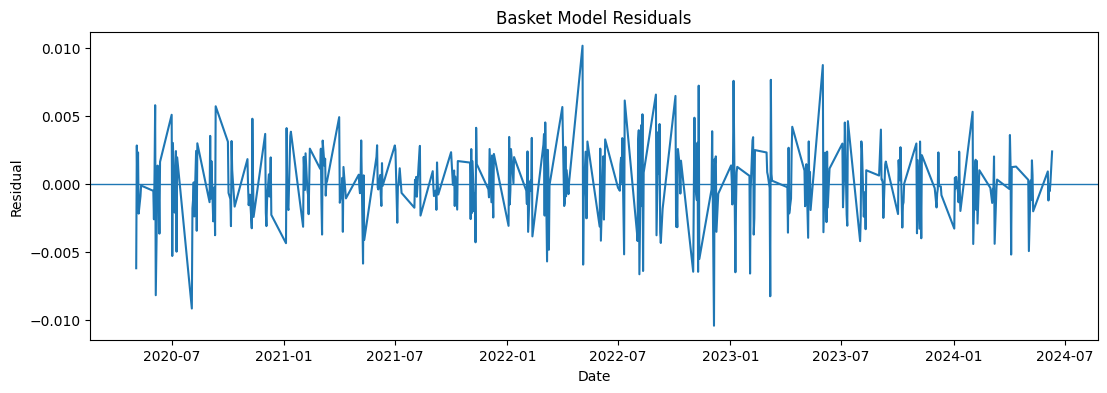

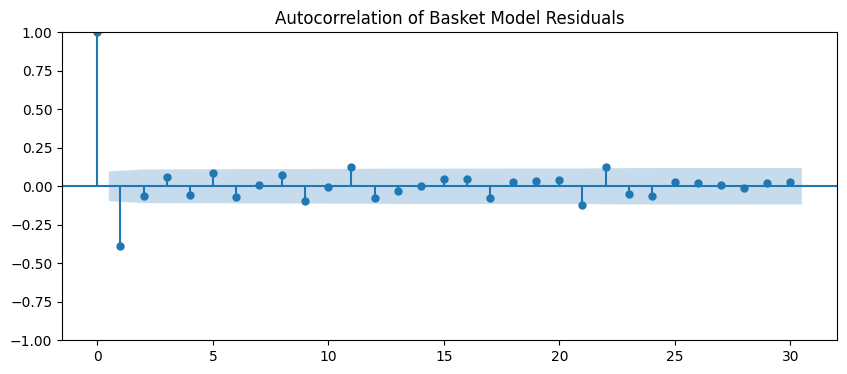

In [11]:
# ================================
# 5.1.2 Basket model residual diagnostics
# ================================

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf

basket_residuals = pd.Series(basket_log_model.resid, index=train.index, name="basket_residuals").dropna()
ljung_box = acorr_ljungbox(basket_residuals, lags=[5, 10, 20], return_df=True)
ljung_box.index.name = "Lag"
try:
    arch_stat = het_arch(basket_residuals, nlags=10)
    arch_results = pd.DataFrame({"Test": ["ARCH LM"], "Statistic": [arch_stat[0]], "p-value": [arch_stat[1]]})
except Exception:
    arch_results = pd.DataFrame({"Test": ["ARCH LM"], "Statistic": [np.nan], "p-value": [np.nan]})

display(ljung_box)
display(arch_results)

plt.figure(figsize=(13,4))
plt.plot(df_model.loc[basket_residuals.index, "date"], basket_residuals)
plt.axhline(0, linewidth=1)
plt.title("Basket Model Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(basket_residuals, lags=min(30, max(1, len(basket_residuals)//3)), ax=ax)
ax.set_title("Autocorrelation of Basket Model Residuals")
plt.show()


In [12]:
# ================================
# 5.2 Benchmark: percentage-change regression
# ================================

pct_vars = ["pct_eurusd", "pct_gbpusd", "pct_usdjpy"]
pct_sample = df.dropna(subset=["pct_usd_tnd_fix"] + pct_vars).copy()
pct_train_end = int(len(pct_sample) * 0.75)

pct_model = OLS(
    pct_sample.iloc[:pct_train_end]["pct_usd_tnd_fix"],
    add_constant(pct_sample.iloc[:pct_train_end][pct_vars])
).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(pct_model.summary())


                            OLS Regression Results                            
Dep. Variable:        pct_usd_tnd_fix   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     138.1
Date:                Mon, 04 May 2026   Prob (F-statistic):           7.39e-62
Time:                        14:11:53   Log-Likelihood:                 1841.5
No. Observations:                 414   AIC:                            -3675.
Df Residuals:                     410   BIC:                            -3659.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   7.57e-05      2.030      0.0

In [13]:
# ================================
# 5.3 Rolling basket model: coefficient stability
# ================================

ROLLING_WINDOW = min(120, max(50, len(df_model)//3))
rolling_rows = []

for i in range(ROLLING_WINDOW, len(df_model)):
    window = df_model.iloc[i-ROLLING_WINDOW:i]
    current = df_model.iloc[i]
    m = OLS(window["r_usd_tnd_fix"], add_constant(window[basket_vars])).fit()
    pred = m.predict(add_constant(pd.DataFrame([current[basket_vars].values], columns=basket_vars), has_constant="add"))[0]
    rolling_rows.append({
        "date": current["date"],
        "basket_return_rolling": pred,
        "beta_eurusd": m.params.get("r_eurusd", np.nan),
        "beta_gbpusd": m.params.get("r_gbpusd", np.nan),
        "beta_usdjpy": m.params.get("r_usdjpy", np.nan),
        "r2": m.rsquared
    })

rolling_basket = pd.DataFrame(rolling_rows)
df_model = df_model.merge(rolling_basket[["date", "basket_return_rolling"]], on="date", how="left")
df_model["basket_return_final"] = df_model["basket_return_rolling"].fillna(df_model["basket_return_static"])
df_model["baseline_static"] = df_model["usd_tnd_fix"].shift(1) * np.exp(df_model["basket_return_static"])
df_model["baseline_rolling"] = df_model["usd_tnd_fix"].shift(1) * np.exp(df_model["basket_return_final"])
rolling_basket.tail()


,date,basket_return_rolling,beta_eurusd,beta_gbpusd,beta_usdjpy,r2
427,2025-12-04,0.001063,-0.481072,-0.135326,0.069812,0.803031
428,2025-12-08,0.000591,-0.484830,-0.130779,0.074101,0.802457
429,2025-12-09,0.000866,-0.480790,-0.138949,0.067439,0.804290
430,2025-12-10,-0.004098,-0.482526,-0.135785,0.068006,0.804405
431,2025-12-11,-0.002196,-0.478993,-0.134070,0.069943,0.799548


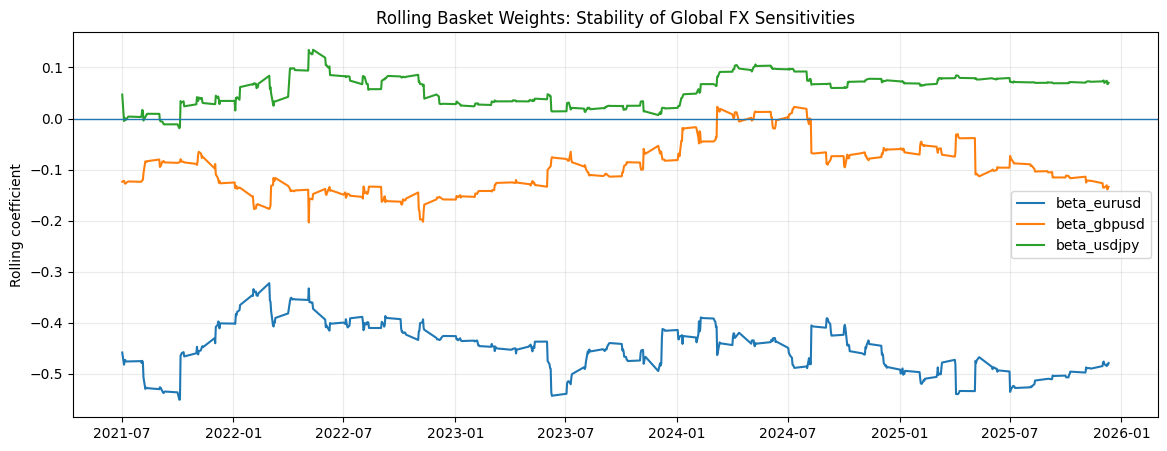

In [14]:
# ================================
# 5.4 Basket coefficient stability chart
# ================================

fig, ax = plt.subplots(figsize=(14,5))
for col in ["beta_eurusd", "beta_gbpusd", "beta_usdjpy"]:
    ax.plot(rolling_basket["date"], rolling_basket[col], label=col)
ax.axhline(0, linewidth=1)
ax.set_title("Rolling Basket Weights: Stability of Global FX Sensitivities")
ax.set_ylabel("Rolling coefficient")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 7. Local Liquidity Adjustment Model

The second layer models the deviation between the baseline/fixing framework and the real interbank market. The observed liquidity spread is:

$$
Spread_t = IB_t - Fixing_t
$$

This spread is interpreted as the local market pressure component. When the spread widens, interbank participants are pricing USD above the official benchmark. When it narrows or turns negative, the interbank market is less stressed relative to the fixing.

The adjustment model combines three ideas:

1. **Autoregressive persistence** — liquidity pressure tends to carry over from one day to the next.  
2. **Kalman filtering** — the observed spread is noisy, so a latent smooth liquidity-pressure state is estimated.  
3. **Regime awareness** — liquidity behavior can differ between normal and high-stress periods.

The adjustment is estimated from data rather than hardcoded. This avoids arbitrary blending weights and makes the liquidity layer empirically defensible.

## 8. Kalman Filter Liquidity State

The Kalman filter estimates an unobserved liquidity state from the observed spread. The state-space representation is:

$$
x_t = A x_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0,Q)
$$

$$
y_t = Hx_t + v_t, \quad v_t \sim \mathcal{N}(0,R)
$$

Here, \(y_t\) is the observed interbank-fixing spread and \(x_t\) is the latent liquidity-pressure state. The Kalman estimate is useful because the interbank spread can contain day-to-day noise, while the underlying pressure process is usually smoother.

### 6.4 Fixing Anchor Sensitivity Analysis

The project brief identifies an important modeling question: should the liquidity spread be measured against today's fixing, yesterday's fixing, or an alternative intraday-style anchor? This section compares alternative spread definitions using the same autoregressive liquidity regression and selects the anchor with the strongest statistical fit.

In [15]:
# ================================
# 6.4 Fixing Anchor Sensitivity Analysis
# ================================

anchor_df = df_model.copy()
anchor_df["spread_vs_current"] = anchor_df["usd_tnd_ib"] - anchor_df["usd_tnd_fix"]
anchor_df["spread_vs_lag1"] = anchor_df["usd_tnd_ib"] - anchor_df["usd_tnd_fix"].shift(1)
anchor_df["usd_tnd_cross_anchor"] = anchor_df["eur_tnd_fix"] / anchor_df["eurusd"]
anchor_df["spread_vs_cross_anchor"] = anchor_df["usd_tnd_ib"] - anchor_df["usd_tnd_cross_anchor"]

anchor_candidates = {
    "Current fixing anchor": "spread_vs_current",
    "Previous-day fixing anchor": "spread_vs_lag1",
    "EUR/TND cross-implied anchor": "spread_vs_cross_anchor",
}
anchor_results = []
anchor_models = {}
for anchor_name, spread_col in anchor_candidates.items():
    tmp = anchor_df[["date", spread_col]].rename(columns={spread_col: "candidate_spread"}).dropna().copy()
    tmp["lag1"] = tmp["candidate_spread"].shift(1)
    tmp["lag2"] = tmp["candidate_spread"].shift(2)
    tmp["roll_mean_20"] = tmp["candidate_spread"].rolling(20).mean()
    tmp["roll_vol_20"] = tmp["candidate_spread"].rolling(20).std()
    tmp = tmp.dropna()
    if len(tmp) < 40:
        continue
    features = ["lag1", "lag2", "roll_mean_20", "roll_vol_20"]
    m = LinearRegression().fit(tmp[features], tmp["candidate_spread"])
    pred = m.predict(tmp[features])
    resid = tmp["candidate_spread"].values - pred
    rss = float(np.sum(resid ** 2))
    n = len(tmp)
    k = len(features) + 1
    aic = n * np.log(max(rss / n, 1e-12)) + 2 * k
    anchor_results.append({"Anchor": anchor_name, "Spread Column": spread_col, "R2": m.score(tmp[features], tmp["candidate_spread"]), "Residual Std": float(np.std(resid, ddof=1)), "AIC": aic, "Observations": n})
    anchor_models[anchor_name] = m

anchor_sensitivity = pd.DataFrame(anchor_results).sort_values(["AIC", "Residual Std", "R2"], ascending=[True, True, False])
selected_anchor_name = anchor_sensitivity.iloc[0]["Anchor"]
selected_spread_col = anchor_sensitivity.iloc[0]["Spread Column"]

df_model["spread_original_current"] = df_model["spread"]
for col in ["spread_vs_current", "spread_vs_lag1", "spread_vs_cross_anchor", "usd_tnd_cross_anchor"]:
    df_model[col] = anchor_df[col]

df_model["selected_anchor"] = selected_anchor_name
df_model["spread"] = df_model[selected_spread_col]
df_model["spread_bps"] = 10000 * df_model["spread"] / df_model["usd_tnd_fix"]
df_model["spread_lag1"] = df_model["spread"].shift(1)
df_model["spread_lag2"] = df_model["spread"].shift(2)
df_model["spread_roll_mean_20"] = df_model["spread"].rolling(20).mean()
df_model["spread_roll_vol_20"] = df_model["spread"].rolling(20).std()

print(f"Selected liquidity anchor: {selected_anchor_name}")
print("Financial interpretation: the selected anchor provides the most stable and explainable spread dynamics under the same autoregressive structure.")
print("Economically, this means the market premium is best measured against the benchmark that most closely matches how interbank participants appear to price USD/TND liquidity pressure.")
anchor_sensitivity


Selected liquidity anchor: Previous-day fixing anchor
Financial interpretation: the selected anchor provides the most stable and explainable spread dynamics under the same autoregressive structure.
Economically, this means the market premium is best measured against the benchmark that most closely matches how interbank participants appear to price USD/TND liquidity pressure.


,Anchor,Spread Column,R2,Residual Std,AIC,Observations
1,Previous-day fixing anchor,spread_vs_lag1,0.548072,0.075666,"-2,737.641877",532
2,EUR/TND cross-implied anchor,spread_vs_cross_anchor,0.533202,0.077258,"-2,720.608973",533
0,Current fixing anchor,spread_vs_current,0.532187,0.077331,"-2,719.605718",533


### 6.5 Maximum-Likelihood Calibration of the Kalman Liquidity State

The Kalman liquidity state depends on two variance parameters: the state-transition variance \(Q\) and the observation variance \(R\). These parameters are estimated by maximum likelihood instead of being set heuristically. MLE parameters are preferred because they choose the state-noise and measurement-noise balance that best explains the observed spread data, making the latent liquidity-pressure estimate statistically defensible rather than manually tuned.

,Parameter,Estimate
0,Q: State Transition Variance,0.006347
1,R: Observation Variance,0.000503
2,Negative Log-Likelihood,-572.616446


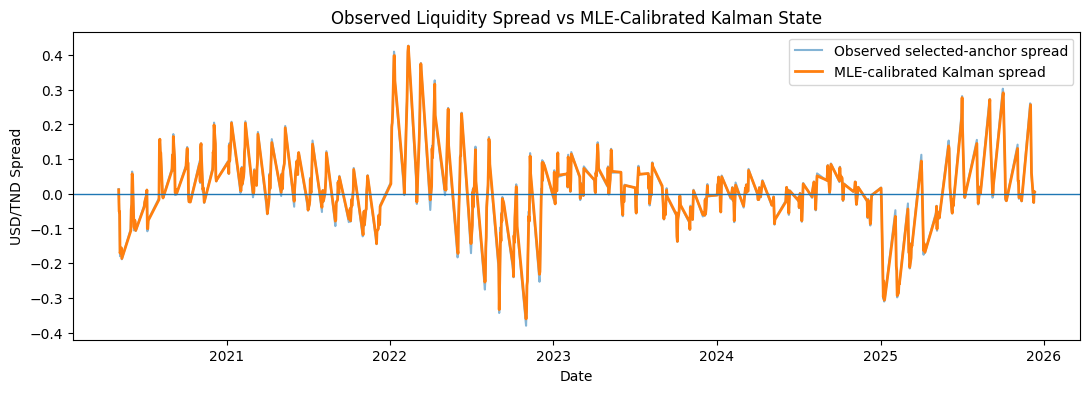

In [16]:
# ================================
# 6.5 Maximum-likelihood calibration for Kalman Q and R
# ================================

from scipy.optimize import minimize

def kalman_filter_mle(y, Q, R, x0=None, P0=None):
    """One-dimensional local-level Kalman filter with explicit Q and R."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    x_filtered = np.zeros(n)
    P_filtered = np.zeros(n)
    finite_y = y[np.isfinite(y)]
    x = np.nanmean(finite_y[:min(10, len(finite_y))]) if x0 is None and len(finite_y) else (0.0 if x0 is None else x0)
    P = np.nanvar(finite_y) if P0 is None and len(finite_y) else (1.0 if P0 is None else P0)
    if not np.isfinite(P) or P <= 0:
        P = 1.0
    neg_loglik = 0.0
    for t in range(n):
        x_pred = x
        P_pred = P + Q
        if np.isfinite(y[t]):
            innovation = y[t] - x_pred
            S = P_pred + R
            if S <= 0 or not np.isfinite(S):
                return None, None, np.inf
            K = P_pred / S
            x = x_pred + K * innovation
            P = (1 - K) * P_pred
            neg_loglik += 0.5 * (np.log(2 * np.pi) + np.log(S) + (innovation ** 2) / S)
        else:
            x, P = x_pred, P_pred
        x_filtered[t] = x
        P_filtered[t] = P
    return x_filtered, P_filtered, neg_loglik

def kalman_neg_loglik(log_params, y):
    Q = np.exp(log_params[0])
    R = np.exp(log_params[1])
    _, _, nll = kalman_filter_mle(y, Q, R)
    return nll

spread_for_kalman = pd.to_numeric(df_model["spread"], errors="coerce").dropna()
spread_values = spread_for_kalman.values
initial_var = np.nanvar(spread_values)
initial_Q = max(initial_var * 0.05, 1e-8)
initial_R = max(initial_var * 0.50, 1e-8)
opt = minimize(kalman_neg_loglik, x0=np.log([initial_Q, initial_R]), args=(spread_values,), method="Nelder-Mead", options={"maxiter": 5000})
Q_mle, R_mle = np.exp(opt.x)
kalman_state_mle, kalman_var_mle, kalman_nll = kalman_filter_mle(spread_values, Q_mle, R_mle)
df_model.loc[spread_for_kalman.index, "kalman_spread_mle"] = kalman_state_mle
df_model.loc[spread_for_kalman.index, "kalman_var_mle"] = kalman_var_mle
df_model["kalman_lag1_mle"] = df_model["kalman_spread_mle"].shift(1)
kalman_calibration = pd.DataFrame({"Parameter": ["Q: State Transition Variance", "R: Observation Variance", "Negative Log-Likelihood"], "Estimate": [Q_mle, R_mle, kalman_nll]})
display(kalman_calibration)
plt.figure(figsize=(13,4))
plt.plot(df_model["date"], df_model["spread"], label="Observed selected-anchor spread", alpha=0.55)
plt.plot(df_model["date"], df_model["kalman_spread_mle"], label="MLE-calibrated Kalman spread", linewidth=2)
plt.axhline(0, linewidth=1)
plt.title("Observed Liquidity Spread vs MLE-Calibrated Kalman State")
plt.xlabel("Date")
plt.ylabel("USD/TND Spread")
plt.legend()
plt.show()


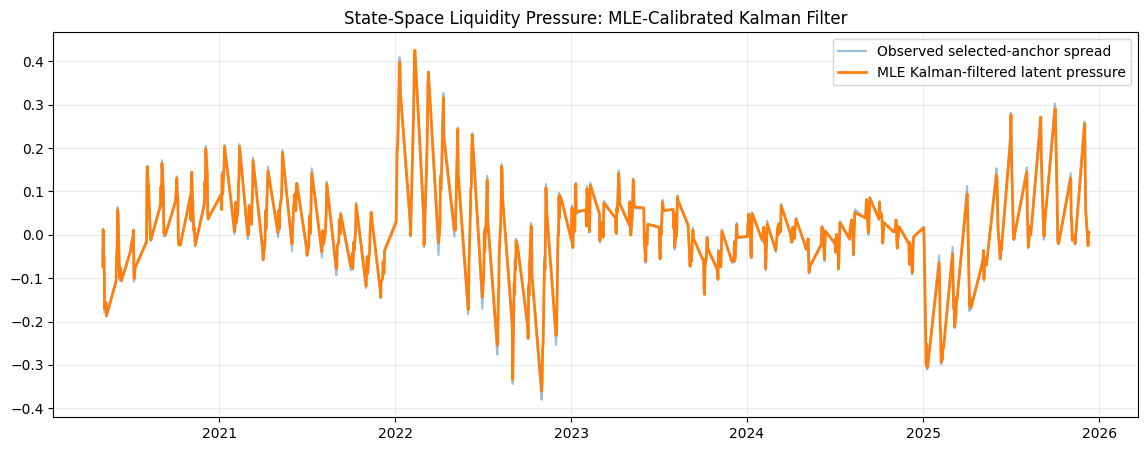

In [17]:
# ================================
# 6.1 Kalman filter from first principles
# ================================

# The filter is driven by Q_mle and R_mle, which were estimated by maximum likelihood rather than selected heuristically.
kf_mean, kf_var, _ = kalman_filter_mle(df_model["spread"].values, Q_mle, R_mle)
df_model["kalman_spread_insample"] = kf_mean
df_model["kalman_var_mle"] = kf_var
df_model["kalman_lag1"] = df_model["kalman_spread_insample"].shift(1)

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df_model["date"], df_model["spread"], label="Observed selected-anchor spread", alpha=0.45)
ax.plot(df_model["date"], df_model["kalman_spread_insample"], label="MLE Kalman-filtered latent pressure", linewidth=2)
ax.set_title("State-Space Liquidity Pressure: MLE-Calibrated Kalman Filter")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


In [18]:
# ================================
# 6.2 Regime-aware stress indicator
# ================================

df_model["spread_vol_20"] = df_model["spread"].rolling(20).std()
stress_cutoff = df_model["spread_vol_20"].quantile(0.75)
df_model["regime"] = np.where(df_model["spread_vol_20"] > stress_cutoff, "High Stress", "Normal")

regime_stats = df_model.groupby("regime").agg(
    obs=("spread", "count"),
    avg_spread=("spread", "mean"),
    spread_vol=("spread", "std"),
    avg_spread_bps=("spread_bps", "mean")
)
regime_stats


,obs,avg_spread,spread_vol,avg_spread_bps
regime,,,,
High Stress,133,0.024980,0.176032,96.255711
Normal,418,0.006486,0.081941,27.412594


In [19]:
# ================================
# 6.3 Data-driven liquidity adjustment model
# ================================

liq = df_model.copy()
liq["kalman_lag1"] = liq["kalman_spread_insample"].shift(1)
liq["spread_roll_mean_20"] = liq["spread"].rolling(20).mean()
liq["spread_roll_vol_20"] = liq["spread"].rolling(20).std()
liq["high_stress_dummy"] = (liq["regime"] == "High Stress").astype(int)

df_model["kalman_lag1"] = liq["kalman_lag1"]
df_model["spread_roll_mean_20"] = liq["spread_roll_mean_20"]
df_model["spread_roll_vol_20"] = liq["spread_roll_vol_20"]
df_model["high_stress_dummy"] = liq["high_stress_dummy"]

liq_features = ["spread_lag1", "spread_lag2", "spread_roll_mean_20", "spread_roll_vol_20", "kalman_lag1", "high_stress_dummy"]
liq_train = liq.dropna(subset=liq_features + ["spread"]).copy()
liq_train_end = int(len(liq_train) * 0.75)
liq_model = LinearRegression().fit(liq_train.iloc[:liq_train_end][liq_features], liq_train.iloc[:liq_train_end]["spread"])
liq_train["adjustment_estimate_insample"] = liq_model.predict(liq_train[liq_features])
pd.DataFrame({"feature": liq_features, "estimated_weight": liq_model.coef_})


,feature,estimated_weight
0,spread_lag1,26.312653
1,spread_lag2,1.607268
2,spread_roll_mean_20,0.510507
3,spread_roll_vol_20,0.540187
4,kalman_lag1,-27.561725
5,high_stress_dummy,-0.049217


## 9. Regime-Aware Market Pressure

Liquidity pressure is not constant across time. During calm periods, spreads may fluctuate in a narrow range. During stressed periods, the same spread level can carry a different interpretation because volatility is higher and liquidity is thinner.

The notebook classifies stress regimes using rolling spread volatility. A higher-volatility regime is interpreted as a high-stress liquidity environment. This regime indicator is then included as an explanatory feature in the liquidity adjustment model.

This creates a simple but powerful market diagnostic: the same USD/TND level is interpreted differently depending on whether the market is calm or stressed.

## 10. Real-Time Intrinsic Value Engine

The final valuation engine combines the global baseline and the estimated local adjustment:

$$
\widehat{Intrinsic\ USD/TND}_t
=
\widehat{Baseline}_t
+
\widehat{Adjustment}_t
$$

The production-style nowcast function takes four inputs:

1. the latest available BCT fixing,  
2. current global FX levels,  
3. previous global FX levels,  
4. the latest liquidity-state features.

It then returns the expected basket return, the baseline fair value, the estimated local liquidity adjustment, and the final intrinsic USD/TND value. This is the core monitoring engine of the project.

In [20]:
# ================================
# 7.1 Diagnostic intrinsic value and confidence bands
# ================================

df_model = df_model.merge(liq_train[["date", "adjustment_estimate_insample"]], on="date", how="left")
df_model["intrinsic_insample"] = df_model["baseline_rolling"] + df_model["adjustment_estimate_insample"]
df_model["intrinsic_upper"] = df_model["intrinsic_insample"] + 1.96 * np.sqrt(df_model["kalman_var_mle"])
df_model["intrinsic_lower"] = df_model["intrinsic_insample"] - 1.96 * np.sqrt(df_model["kalman_var_mle"])
resid = df_model["usd_tnd_ib"] - df_model["intrinsic_insample"]
df_model["resid_vol_60"] = resid.rolling(60).std()
df_model["intrinsic_empirical_upper"] = df_model["intrinsic_insample"] + 1.96 * df_model["resid_vol_60"]
df_model["intrinsic_empirical_lower"] = df_model["intrinsic_insample"] - 1.96 * df_model["resid_vol_60"]
latest = df_model.dropna(subset=["intrinsic_insample"]).iloc[-1]
latest_output = {"date": latest["date"], "official_fixing": latest["usd_tnd_fix"], "interbank_market": latest["usd_tnd_ib"], "baseline": latest["baseline_rolling"], "liquidity_adjustment": latest["adjustment_estimate_insample"], "intrinsic_value": latest["intrinsic_insample"], "market_gap_vs_intrinsic": latest["usd_tnd_ib"] - latest["intrinsic_insample"], "selected_anchor": latest.get("selected_anchor", selected_anchor_name)}
latest_output


{'date': Timestamp('2025-12-11 00:00:00'),
 'official_fixing': np.float64(2.9223),
 'interbank_market': np.float64(2.9469),
 'baseline': np.float64(2.934847159890024),
 'liquidity_adjustment': np.float64(0.067502564000526),
 'intrinsic_value': np.float64(3.00234972389055),
 'market_gap_vs_intrinsic': np.float64(-0.05544972389055003),
 'selected_anchor': 'Previous-day fixing anchor'}

## 11. Backtesting and Out-of-Sample Evaluation

The backtest evaluates whether the intrinsic value improves the forecast of the next available interbank USD/TND rate relative to a fixing-only benchmark.

To avoid look-ahead bias, the rolling backtest re-estimates the basket model and liquidity adjustment model using only information available up to each forecast date. Future spread information is not used to produce the forecast. This is essential because pre-fitting the Kalman or regime model on the full sample would leak future market information into the historical test.

The main evaluation metrics are:

- **RMSE** — penalizes larger forecast errors.  
- **MAE** — measures average absolute error.  
- **MAPE** — expresses error relative to the actual interbank level.  
- **Directional accuracy** — tests whether the model captures the direction of the next interbank move.

The comparison against the fixing-only benchmark shows whether the liquidity adjustment adds practical forecasting value.

In [21]:
# ================================
# 8.1 Production-style nowcast function
# ================================

def fairflow_nowcast(latest_fixing, current_fx, previous_fx, basket_model, adjustment_model, latest_state):
    """
    One-step FairFlow nowcast.

    Inputs:
    - latest_fixing: latest observed BCT USD/TND fixing
    - current_fx: current EUR/USD, GBP/USD, USD/JPY levels
    - previous_fx: previous reference FX levels
    - basket_model: fitted global basket regression
    - adjustment_model: fitted liquidity adjustment model
    - latest_state: latest local liquidity state features

    Output:
    - baseline basket value
    - estimated local liquidity adjustment
    - intrinsic USD/TND fair value
    """

    returns = {
        "r_eurusd": np.log(float(current_fx["eurusd"]) / float(previous_fx["eurusd"])),
        "r_gbpusd": np.log(float(current_fx["gbpusd"]) / float(previous_fx["gbpusd"])),
        "r_usdjpy": np.log(float(current_fx["usdjpy"]) / float(previous_fx["usdjpy"])),
    }

    Xb = add_constant(pd.DataFrame([returns]), has_constant="add")
    expected_return = float(basket_model.predict(Xb)[0])
    baseline = float(latest_fixing) * np.exp(expected_return)

    Xl = pd.DataFrame([latest_state]).reindex(columns=liq_features)
    adjustment = float(adjustment_model.predict(Xl)[0])
    intrinsic = baseline + adjustment

    return {
        "expected_basket_return": expected_return,
        "baseline": baseline,
        "estimated_adjustment": adjustment,
        "intrinsic_usd_tnd": intrinsic
    }


# Make sure real-time features exist even if this cell is run independently.
df_model["kalman_lag1"] = df_model.get("kalman_lag1", df_model["kalman_spread_insample"].shift(1))
df_model["spread_roll_mean_20"] = df_model.get("spread_roll_mean_20", df_model["spread"].rolling(20).mean())
df_model["spread_roll_vol_20"] = df_model.get("spread_roll_vol_20", df_model["spread"].rolling(20).std())
df_model["high_stress_dummy"] = df_model.get("high_stress_dummy", (df_model["regime"] == "High Stress").astype(int))

rt_ready = df_model.dropna(subset=liq_features).copy()

if len(rt_ready) < 2:
    raise ValueError("Not enough observations for real-time demo after liquidity feature construction.")

last = rt_ready.iloc[-1]
prev = rt_ready.iloc[-2]

latest_state = {
    "spread_lag1": last["spread_lag1"],
    "spread_lag2": last["spread_lag2"],
    "spread_roll_mean_20": last["spread_roll_mean_20"],
    "spread_roll_vol_20": last["spread_roll_vol_20"],
    "kalman_lag1": last["kalman_lag1"],
    "high_stress_dummy": int(last["high_stress_dummy"])
}

realtime_demo = fairflow_nowcast(
    latest_fixing=prev["usd_tnd_fix"],
    current_fx={"eurusd": last["eurusd"], "gbpusd": last["gbpusd"], "usdjpy": last["usdjpy"]},
    previous_fx={"eurusd": prev["eurusd"], "gbpusd": prev["gbpusd"], "usdjpy": prev["usdjpy"]},
    basket_model=basket_log_model,
    adjustment_model=liq_model,
    latest_state=latest_state
)

realtime_demo


{'expected_basket_return': -0.001754903877765973,
 'baseline': np.float64(2.9361428277186845),
 'estimated_adjustment': 0.06750256400052597,
 'intrinsic_usd_tnd': np.float64(3.0036453917192105)}

## 12. Dashboard and Signature Indicators

The final dashboard summarizes the engine as a compact USD/TND monitoring tool. It includes:

- official BCT fixing,  
- observed interbank market rate,  
- global basket baseline,  
- local liquidity adjustment,  
- final intrinsic value,  
- confidence bands,  
- market pressure gauge,  
- liquidity stress indicator.

The **Market Pressure Gauge** compares the latest interbank value against the intrinsic estimate. If the interbank rate is above intrinsic value, USD/TND is trading rich relative to fair value. If it is below intrinsic value, USD/TND is trading cheap relative to fair value.

The **Liquidity Stress Indicator** standardizes the spread into a z-score, allowing the latest market pressure to be interpreted relative to its own history.

In [22]:
# ================================
# 9.1 Rolling out-of-sample backtest
# ================================

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 1e-12)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

bt_rows = []
MIN_TRAIN = min(120, max(60, int(len(df_model)*0.45)))
work = df_model.copy().reset_index(drop=True)
for i in range(MIN_TRAIN, len(work)-1, 5):
    hist = work.iloc[:i].copy()
    current = work.iloc[i].copy()
    target = work.iloc[i+1].copy()
    hist_clean = hist.dropna(subset=["r_usd_tnd_fix"] + basket_vars + ["spread", "spread_lag1", "spread_lag2"])
    if len(hist_clean) < 50:
        continue
    b_model = LinearRegression().fit(hist_clean[basket_vars], hist_clean["r_usd_tnd_fix"])
    cur_fx_vals = current[basket_vars].astype(float)
    if cur_fx_vals.isnull().any() or (~np.isfinite(cur_fx_vals)).any():
        continue
    pred_return = float(b_model.predict(pd.DataFrame([cur_fx_vals.values], columns=basket_vars))[0])
    baseline_oos = float(current["usd_tnd_fix"] * np.exp(pred_return))
    kf_hist, kf_hist_var, _ = kalman_filter_mle(hist_clean["spread"].values, Q_mle, R_mle)
    kalman_last = float(kf_hist[-1])
    h = hist_clean.copy()
    h["kalman_lag1_oos"] = pd.Series(kf_hist, index=h.index).shift(1)
    h["spread_roll_mean_20_oos"] = h["spread"].rolling(20).mean()
    h["spread_roll_vol_20_oos"] = h["spread"].rolling(20).std()
    cutoff = h["spread_roll_vol_20_oos"].quantile(0.75)
    h["high_stress_dummy_oos"] = (h["spread_roll_vol_20_oos"] > cutoff).astype(int)
    oos_features = ["spread_lag1", "spread_lag2", "spread_roll_mean_20_oos", "spread_roll_vol_20_oos", "kalman_lag1_oos", "high_stress_dummy_oos"]
    h2 = h.dropna(subset=oos_features + ["spread"])
    if len(h2) < 50:
        continue
    l_model = LinearRegression().fit(h2[oos_features], h2["spread"])
    current_liq = pd.DataFrame([{ "spread_lag1": current["spread_lag1"], "spread_lag2": current["spread_lag2"], "spread_roll_mean_20_oos": hist_clean["spread"].tail(20).mean(), "spread_roll_vol_20_oos": hist_clean["spread"].tail(20).std(), "kalman_lag1_oos": kalman_last, "high_stress_dummy_oos": int(hist_clean["spread"].tail(20).std() > cutoff)}])
    if current_liq.isnull().any(axis=None):
        continue
    adj_oos = float(l_model.predict(current_liq[oos_features])[0])
    intrinsic_oos = baseline_oos + adj_oos
    bt_rows.append({"forecast_date": current["date"], "target_date": target["date"], "baseline_oos": baseline_oos, "adjustment_oos": adj_oos, "intrinsic_oos": intrinsic_oos, "fixing_only_forecast": current["usd_tnd_fix"], "actual_next_ib": target["usd_tnd_ib"], "actual_current_fix": current["usd_tnd_fix"], "actual_current_ib": current["usd_tnd_ib"], "regime": current.get("regime", np.nan), "selected_anchor": current.get("selected_anchor", selected_anchor_name)})
bt = pd.DataFrame(bt_rows).dropna()
print(f"Backtest observations: {len(bt)}")
bt.head()


Backtest observations: 87


,forecast_date,target_date,baseline_oos,adjustment_oos,intrinsic_oos,fixing_only_forecast,actual_next_ib,actual_current_fix,actual_current_ib,regime,selected_anchor
0,2021-07-02,2021-07-05,2.781790,0.009650,2.791440,2.784700,2.754900,2.784700,2.732300,Normal,Previous-day fixing anchor
1,2021-07-09,2021-07-12,2.772990,0.058577,2.831567,2.779100,2.932500,2.779100,2.783700,Normal,Previous-day fixing anchor
2,2021-08-05,2021-08-06,2.779562,0.047142,2.826703,2.780000,2.762700,2.780000,2.754900,Normal,Previous-day fixing anchor
3,2021-09-01,2021-09-02,2.779397,0.073821,2.853218,2.790700,2.715700,2.790700,2.705800,Normal,Previous-day fixing anchor
4,2021-09-08,2021-09-09,2.793745,0.027577,2.821322,2.790300,2.792000,2.790300,2.794400,Normal,Previous-day fixing anchor


In [23]:
# ================================
# 9.2 Evaluation metrics and regime-conditional performance
# ================================

metrics = pd.DataFrame({"Model": ["Fixing-only benchmark", "FairFlow intrinsic engine"], "RMSE": [np.sqrt(mean_squared_error(bt["actual_next_ib"], bt["fixing_only_forecast"])), np.sqrt(mean_squared_error(bt["actual_next_ib"], bt["intrinsic_oos"]))], "MAE": [mean_absolute_error(bt["actual_next_ib"], bt["fixing_only_forecast"]), mean_absolute_error(bt["actual_next_ib"], bt["intrinsic_oos"])], "MAPE (%)": [safe_mape(bt["actual_next_ib"], bt["fixing_only_forecast"]), safe_mape(bt["actual_next_ib"], bt["intrinsic_oos"])]})
bt["direction_actual"] = np.sign(bt["actual_next_ib"].diff())
bt["direction_pred"] = np.sign(bt["intrinsic_oos"].diff())
dir_mask = bt["direction_actual"].notna() & bt["direction_pred"].notna()
metrics["Directional Accuracy"] = [np.nan, (bt.loc[dir_mask, "direction_actual"] == bt.loc[dir_mask, "direction_pred"]).mean()]
def regime_error_table(group):
    return pd.Series({"FairFlow RMSE": np.sqrt(mean_squared_error(group["actual_next_ib"], group["intrinsic_oos"])), "FairFlow MAE": mean_absolute_error(group["actual_next_ib"], group["intrinsic_oos"]), "Fixing RMSE": np.sqrt(mean_squared_error(group["actual_next_ib"], group["fixing_only_forecast"])), "Fixing MAE": mean_absolute_error(group["actual_next_ib"], group["fixing_only_forecast"]), "Observations": len(group)})
regime_backtest = bt.dropna(subset=["regime"]).groupby("regime").apply(regime_error_table).reset_index()
regime_backtest["RMSE Improvement vs Fixing"] = regime_backtest["Fixing RMSE"] - regime_backtest["FairFlow RMSE"]
regime_backtest["MAE Improvement vs Fixing"] = regime_backtest["Fixing MAE"] - regime_backtest["FairFlow MAE"]
if not regime_backtest.empty:
    stress_row = regime_backtest.loc[regime_backtest["regime"].eq("High Stress")]
    if not stress_row.empty and stress_row["RMSE Improvement vs Fixing"].iloc[0] > 0:
        regime_interpretation = "The liquidity adjustment adds value during high-stress periods, which supports the model's core economic hypothesis."
    else:
        regime_interpretation = "The regime breakdown suggests that stress-period performance should be monitored carefully, because the liquidity adjustment does not always dominate the benchmark."
else:
    regime_interpretation = "Regime-conditional performance could not be computed because no regime labels were available in the backtest sample."
print(regime_interpretation)
display(metrics)
display(regime_backtest)


The liquidity adjustment adds value during high-stress periods, which supports the model's core economic hypothesis.


,Model,RMSE,MAE,MAPE (%),Directional Accuracy
0,Fixing-only benchmark,0.120270,0.085143,2.797994,NaN
1,FairFlow intrinsic engine,0.115377,0.078812,2.619695,0.569767


,regime,FairFlow RMSE,FairFlow MAE,Fixing RMSE,Fixing MAE,Observations,RMSE Improvement vs Fixing,MAE Improvement vs Fixing
0,High Stress,0.160666,0.119280,0.163474,0.125159,29.000000,0.002808,0.005879
1,Normal,0.084030,0.058578,0.091298,0.065134,58.000000,0.007268,0.006556


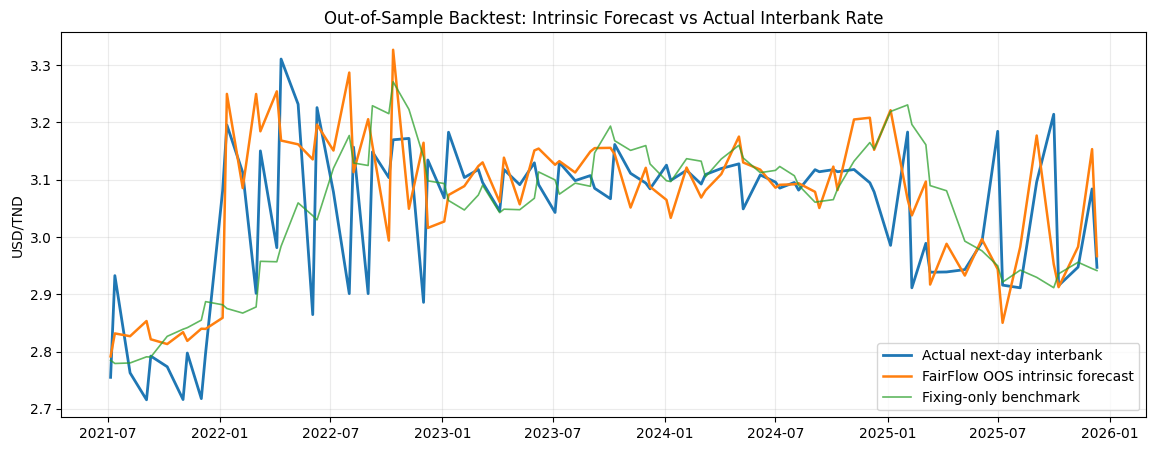

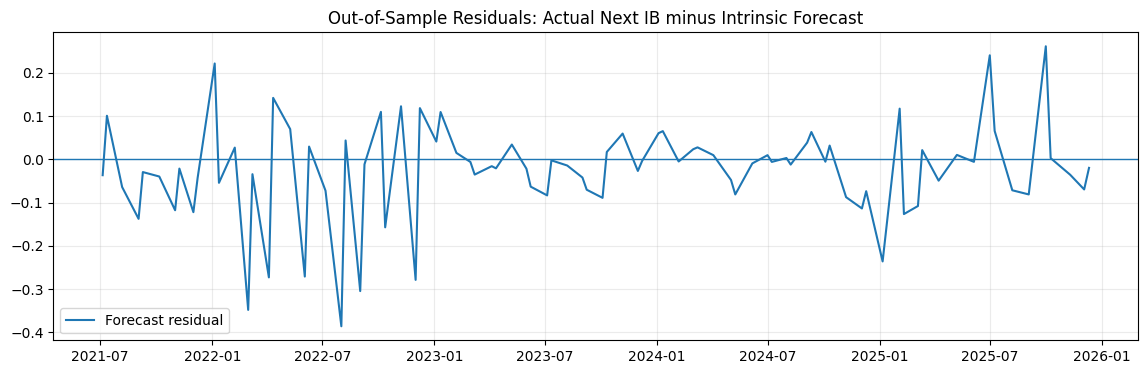

In [24]:
# ================================
# 9.3 Backtest visual diagnostics
# ================================

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(bt["target_date"], bt["actual_next_ib"], label="Actual next-day interbank", linewidth=2)
ax.plot(bt["target_date"], bt["intrinsic_oos"], label="FairFlow OOS intrinsic forecast", linewidth=1.8)
ax.plot(bt["target_date"], bt["fixing_only_forecast"], label="Fixing-only benchmark", linewidth=1.2, alpha=0.75)
ax.set_title("Out-of-Sample Backtest: Intrinsic Forecast vs Actual Interbank Rate")
ax.set_ylabel("USD/TND")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

bt["residual"] = bt["actual_next_ib"] - bt["intrinsic_oos"]
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(bt["target_date"], bt["residual"], label="Forecast residual")
ax.axhline(0, linewidth=1)
ax.set_title("Out-of-Sample Residuals: Actual Next IB minus Intrinsic Forecast")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


### 11.1 Diebold-Mariano Test for Forecast Accuracy

RMSE and MAE report forecast error size, but they do not formally prove that one model has superior predictive accuracy. The Diebold-Mariano test compares the forecast loss differential between the FairFlow intrinsic model and the fixing-only benchmark. A statistically significant positive result means the FairFlow model reduces forecast loss relative to the benchmark.

In [25]:
# ================================
# 11.1 Diebold-Mariano test
# ================================

from scipy import stats

def diebold_mariano_test(actual, forecast_1, forecast_2, h=1, power=2):
    actual = pd.Series(actual).astype(float)
    f1 = pd.Series(forecast_1).astype(float)
    f2 = pd.Series(forecast_2).astype(float)
    aligned = pd.concat([actual, f1, f2], axis=1).dropna()
    a, p1, p2 = aligned.iloc[:,0], aligned.iloc[:,1], aligned.iloc[:,2]
    e1 = a - p1
    e2 = a - p2
    loss_1 = np.abs(e1) ** power
    loss_2 = np.abs(e2) ** power
    d = loss_1 - loss_2
    gamma0 = np.var(d, ddof=1)
    var_d = gamma0
    if h > 1:
        for lag in range(1, h):
            cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
            var_d += 2 * (1 - lag / h) * cov
    dm_stat = d.mean() / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.t.cdf(abs(dm_stat), df=len(d)-1))
    return {"DM Statistic": dm_stat, "p-value": p_value, "Mean Fixing-Only Loss": loss_1.mean(), "Mean FairFlow Loss": loss_2.mean(), "Observations": len(d), "Interpretation": "FairFlow improvement statistically significant at 5%" if p_value < 0.05 and dm_stat > 0 else "No statistically significant FairFlow improvement at 5%"}
dm_results = diebold_mariano_test(bt["actual_next_ib"], bt["fixing_only_forecast"], bt["intrinsic_oos"], h=1, power=2)
pd.DataFrame([dm_results])


,DM Statistic,p-value,Mean Fixing-Only Loss,Mean FairFlow Loss,Observations,Interpretation
0,0.401534,0.689023,0.014465,0.013312,87,No statistically significant FairFlow improvem...


### 11.2 Mincer-Zarnowitz Efficiency Test

The Mincer-Zarnowitz test evaluates whether the forecast is unbiased and efficient. The actual interbank rate is regressed on a constant and the FairFlow forecast. The joint null hypothesis is:

$$
H_0: lpha = 0, \quad eta = 1
$$

If the null is not rejected, the forecast is statistically consistent with unbiased and efficient prediction. If it is rejected, the direction of the intercept and slope indicates whether the model systematically under- or over-reacts to market movements.

In [26]:
# ================================
# 11.2 Mincer-Zarnowitz forecast efficiency test
# ================================

mz_data = bt[["actual_next_ib", "intrinsic_oos"]].dropna().copy()
X_mz = add_constant(mz_data[["intrinsic_oos"]])
y_mz = mz_data["actual_next_ib"]
mz_model = OLS(y_mz, X_mz).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
try:
    mz_ftest = mz_model.f_test("const = 0, intrinsic_oos = 1")
    f_stat = float(mz_ftest.fvalue)
    f_pvalue = float(mz_ftest.pvalue)
except Exception:
    f_stat, f_pvalue = np.nan, np.nan
alpha_hat = mz_model.params.get("const", np.nan)
beta_hat = mz_model.params.get("intrinsic_oos", np.nan)
if np.isfinite(f_pvalue) and f_pvalue >= 0.05:
    mz_interpretation = "The null is not rejected: the FairFlow forecast is statistically consistent with unbiased and efficient prediction."
elif beta_hat < 1:
    mz_interpretation = "The null is rejected: the slope below one suggests the forecast may overreact to variation in actual interbank rates."
else:
    mz_interpretation = "The null is rejected: the slope above one suggests the forecast may underreact to variation in actual interbank rates."
mz_results = pd.DataFrame({"Intercept alpha": [alpha_hat], "Slope beta": [beta_hat], "R2": [mz_model.rsquared], "Joint F-stat H0: alpha=0, beta=1": [f_stat], "Joint p-value": [f_pvalue], "Interpretation": [mz_interpretation]})
print(mz_interpretation)
display(mz_results)
print(mz_model.summary())


The null is rejected: the slope below one suggests the forecast may overreact to variation in actual interbank rates.


,Intercept alpha,Slope beta,R2,"Joint F-stat H0: alpha=0, beta=1",Joint p-value,Interpretation
0,1.054352,0.647958,0.371053,9.167817,0.000248,The null is rejected: the slope below one sugg...


                            OLS Regression Results                            
Dep. Variable:         actual_next_ib   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     28.10
Date:                Mon, 04 May 2026   Prob (F-statistic):           8.98e-07
Time:                        14:11:59   Log-Likelihood:                 73.594
No. Observations:                  87   AIC:                            -143.2
Df Residuals:                      85   BIC:                            -138.3
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.0544      0.378      2.792

## 13. Financial Interpretation

The TND FairFlow Engine separates USD/TND movements into two sources:

1. **Global fundamentals:** movements justified by international FX markets.  
2. **Local pressure:** deviations caused by Tunisian market liquidity and interbank supply-demand conditions.

When the intrinsic value rises because of the basket baseline, the movement is mainly global and fundamental. When the liquidity adjustment widens, the movement is local and friction-driven.

A positive and rising spread indicates that USD is becoming more expensive in the interbank market relative to the official fixing. For a treasury desk, this may signal higher hedging costs or a need to accelerate USD funding. For a policy analyst, it may indicate pressure in domestic FX liquidity. For a risk manager, it identifies periods where official benchmarks may understate actual market execution costs.

In [27]:
# ================================
# 10.1 Market Pressure Gauge
# ================================

dash = df_model.dropna(subset=["baseline_rolling", "adjustment_estimate_insample", "intrinsic_insample"]).copy()
latest = dash.iloc[-1]

market_gap = latest["usd_tnd_ib"] - latest["intrinsic_insample"]
pressure_label = "USD/TND trades ABOVE intrinsic value: USD premium / local liquidity stress" if market_gap > 0 else "USD/TND trades BELOW intrinsic value: discount / softer local pressure"
stress_z = (latest["spread"] - dash["spread"].mean()) / dash["spread"].std()

print("="*72)
print("TND FAIRFLOW ENGINE | MARKET PRESSURE GAUGE")
print("="*72)
print(f"Date:                       {latest['date'].date()}")
print(f"BCT official USD/TND:        {latest['usd_tnd_fix']:.4f}")
print(f"Observed interbank USD/TND:  {latest['usd_tnd_ib']:.4f}")
print(f"Global basket baseline:      {latest['baseline_rolling']:.4f}")
print(f"Liquidity adjustment:        {latest['adjustment_estimate_insample']:.4f}")
print(f"FairFlow intrinsic USD/TND:  {latest['intrinsic_insample']:.4f}")
print(f"Market gap vs intrinsic:     {market_gap:.4f}")
print(f"Liquidity stress z-score:    {stress_z:.2f}")
print("Signal:", pressure_label)
print("="*72)


TND FAIRFLOW ENGINE | MARKET PRESSURE GAUGE
Date:                       2025-12-11
BCT official USD/TND:        2.9223
Observed interbank USD/TND:  2.9469
Global basket baseline:      2.9348
Liquidity adjustment:        0.0675
FairFlow intrinsic USD/TND:  3.0023
Market gap vs intrinsic:     -0.0554
Liquidity stress z-score:    -0.07
Signal: USD/TND trades BELOW intrinsic value: discount / softer local pressure


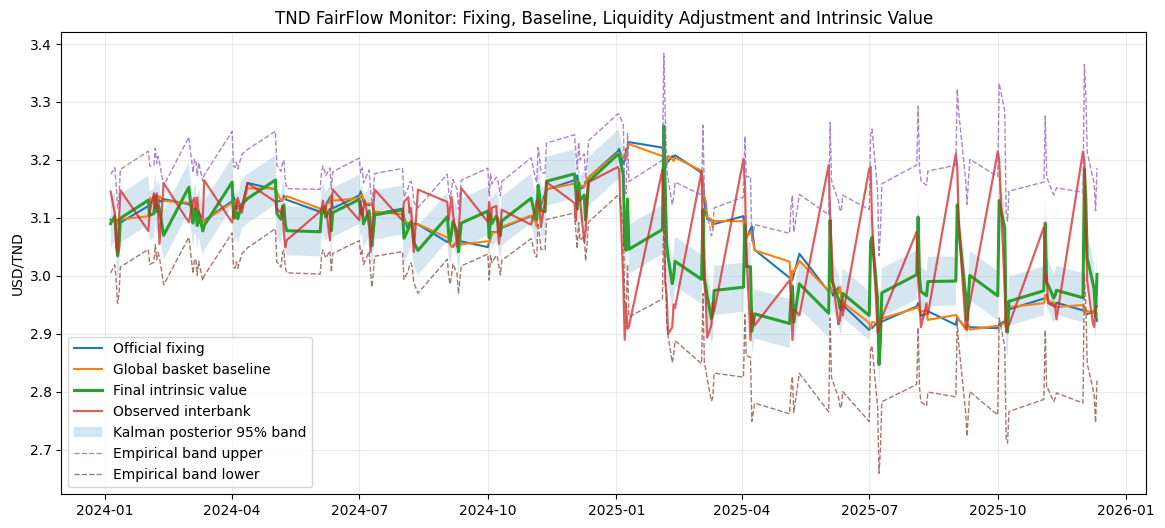

In [28]:
# ================================
# 10.2 Decomposition chart
# ================================

plot_df = dash.tail(180).copy()
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(plot_df["date"], plot_df["usd_tnd_fix"], label="Official fixing", linewidth=1.5)
ax.plot(plot_df["date"], plot_df["baseline_rolling"], label="Global basket baseline", linewidth=1.5)
ax.plot(plot_df["date"], plot_df["intrinsic_insample"], label="Final intrinsic value", linewidth=2.2)
ax.plot(plot_df["date"], plot_df["usd_tnd_ib"], label="Observed interbank", linewidth=1.6, alpha=0.75)
ax.fill_between(plot_df["date"], plot_df["intrinsic_lower"], plot_df["intrinsic_upper"], alpha=0.18, label="Kalman posterior 95% band")
if "intrinsic_empirical_upper" in plot_df.columns:
    ax.plot(plot_df["date"], plot_df["intrinsic_empirical_upper"], linestyle="--", linewidth=1, alpha=0.8, label="Empirical band upper")
    ax.plot(plot_df["date"], plot_df["intrinsic_empirical_lower"], linestyle="--", linewidth=1, alpha=0.8, label="Empirical band lower")
ax.set_title("TND FairFlow Monitor: Fixing, Baseline, Liquidity Adjustment and Intrinsic Value")
ax.set_ylabel("USD/TND")
ax.legend(loc="best")
ax.grid(True, alpha=0.25)
plt.show()


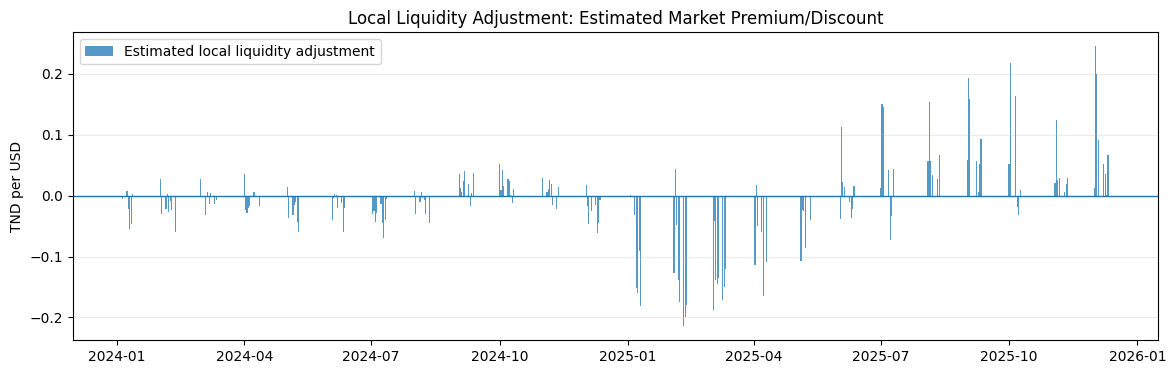

In [29]:
# ================================
# 10.3 Local liquidity adjustment decomposition
# ================================

fig, ax = plt.subplots(figsize=(14,4))
ax.bar(plot_df["date"], plot_df["adjustment_estimate_insample"], label="Estimated local liquidity adjustment", alpha=0.75)
ax.axhline(0, linewidth=1)
ax.set_title("Local Liquidity Adjustment: Estimated Market Premium/Discount")
ax.set_ylabel("TND per USD")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
plt.show()


## 14. Limitations and Extensions

This implementation is based on daily data. A true intraday system would require live EUR/USD, GBP/USD, USD/JPY feeds, intraday BCT fixing timestamps, and more granular Tunisian interbank indications.

The model also relies on historical relationships between global FX movements and USD/TND fixing behavior. If the BCT changes its fixing methodology or if market structure shifts, the estimated basket weights may need recalibration.

Future extensions could include:

- separate testing of morning fixing, evening fixing, and previous-day fixing,  
- higher-frequency intraday global FX updates,  
- macroeconomic variables such as reserves, inflation, and interest-rate differentials,  
- more advanced state-space or Markov-switching models,  
- live dashboard deployment using APIs.

Despite these limitations, the notebook provides a complete empirical framework for intrinsic USD/TND valuation under both global and local market forces.

## 15. Conclusion

The TND FairFlow Engine provides a structured and interpretable valuation framework for USD/TND. It starts from a global FX basket baseline, estimates the local interbank liquidity premium, filters noisy spread dynamics through a latent-state model, and validates the resulting intrinsic value against future interbank observations.

The project demonstrates that USD/TND fair value cannot be understood from the official fixing alone. A stronger valuation system must combine international fundamentals with the realities of local market liquidity. This is the core contribution of the model.

In [30]:
# ================================
# 13.1 Export filled Excel deliverable
# ================================

output_excel = "TND_FairFlow_Engine_Excel.xlsx"
clean_export = df[["date", "usd_tnd_fix", "eur_tnd_fix", "usd_tnd_ib", "eurusd", "gbpusd", "usdjpy", "spread", "spread_bps"]].copy()
basket_export = df_model[["date", "r_usd_tnd_fix", "r_eurusd", "r_gbpusd", "r_usdjpy", "basket_return_static", "basket_return_final", "baseline_static", "baseline_rolling"]].copy()
liquidity_export_cols = ["date", "spread", "spread_bps", "selected_anchor", "kalman_spread_insample", "kalman_var_mle", "regime", "adjustment_estimate_insample"]
liquidity_export = df_model[[c for c in liquidity_export_cols if c in df_model.columns]].copy()
intrinsic_export_cols = ["date", "usd_tnd_fix", "usd_tnd_ib", "baseline_rolling", "adjustment_estimate_insample", "intrinsic_insample", "intrinsic_lower", "intrinsic_upper", "intrinsic_empirical_lower", "intrinsic_empirical_upper"]
intrinsic_export = df_model[[c for c in intrinsic_export_cols if c in df_model.columns]].copy()
dashboard_export = pd.DataFrame([latest_output])
dashboard_export["pressure_signal"] = pressure_label
dashboard_export["liquidity_stress_zscore"] = stress_z
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    clean_export.to_excel(writer, sheet_name="Clean_Data", index=False)
    basket_export.to_excel(writer, sheet_name="Basket_Model", index=False)
    liquidity_export.to_excel(writer, sheet_name="Liquidity_Adjustment", index=False)
    intrinsic_export.to_excel(writer, sheet_name="Intrinsic_Value", index=False)
    bt.to_excel(writer, sheet_name="Backtest", index=False)
    metrics.to_excel(writer, sheet_name="Metrics", index=False)
    regime_backtest.to_excel(writer, sheet_name="Regime_Backtest", index=False)
    anchor_sensitivity.to_excel(writer, sheet_name="Anchor_Sensitivity", index=False)
    stationarity_results.to_excel(writer, sheet_name="Stationarity_Tests", index=False)
    ljung_box.to_excel(writer, sheet_name="Residual_Diagnostics")
    arch_results.to_excel(writer, sheet_name="ARCH_Test", index=False)
    kalman_calibration.to_excel(writer, sheet_name="Kalman_MLE", index=False)
    pd.DataFrame([dm_results]).to_excel(writer, sheet_name="DM_Test", index=False)
    mz_results.to_excel(writer, sheet_name="MZ_Test", index=False)
    dashboard_export.to_excel(writer, sheet_name="Dashboard", index=False)
print(f"Excel deliverable exported: {output_excel}")


Excel deliverable exported: TND_FairFlow_Engine_Excel.xlsx


In [33]:
df.columns

Index(['date', 'usd_tnd_fix', 'eur_tnd_fix', 'usd_tnd_ib', 'eurusd', 'gbpusd',
       'usdjpy', 'spread', 'spread_bps', 'r_usd_tnd_fix', 'r_usd_tnd_ib',
       'r_eur_tnd_fix', 'r_eurusd', 'r_gbpusd', 'r_usdjpy', 'pct_usd_tnd_fix',
       'pct_eurusd', 'pct_gbpusd', 'pct_usdjpy', 'spread_lag1', 'spread_lag2',
       'spread_roll_mean_20', 'spread_roll_vol_20', 'actual_next_ib',
       'target_date', 'spread_vol_20', 'stress_regime'],
      dtype='object')

In [34]:
# === Evaluation Metrics ===
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define true vs predicted
y_true = df["usd_tnd_ib"]
y_pred = df["usd_tnd_fix"]   # replace if you have a model output column

# Remove NaNs (important)
mask = (~y_true.isna()) & (~y_pred.isna())
y_true = y_true[mask]
y_pred = y_pred[mask]

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

# Directional accuracy
direction_true = np.sign(np.diff(y_true))
direction_pred = np.sign(np.diff(y_pred))
directional_accuracy = np.mean(direction_true == direction_pred)

# Output
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"Directional Accuracy: {directional_accuracy}")

RMSE: 0.11311682985792473
MAE: 0.07808589511754069
Directional Accuracy: 0.5036231884057971
